In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# fix relative imports
import os
cwd = os.path.normpath(os.getcwd())
cwd = cwd.split(os.sep)
find = cwd.index("fidelity-phase-tran")
newdir = f"{os.sep}".join(cwd[:find+1])
os.chdir(newdir)

# import known packages
import numpy as np
import pickle
import gzip
import uuid

from matplotlib import pyplot as plt

from scipy import signal

from tenpy.networks.mps import MPS

# import adhoc packages
from qphaset.filters import SOBEL, SOBEL_X, bump_kernel, upsampling_base
from qphaset.fidelity import fidelity_laplacian, uhlmann_fidelity
from qphaset.models import get_rdm, params_2d_lattice
from qphaset.annni import PT_tran, BKT_tran, th_lines

In [ ]:
"""
Type of filename to use:
filename = 'results/data/{model}_{identifier}.pkl'
"""
# filename = 'results/annni-20spins-64x64-dmrg-20240212.pkl'             # First decent ANNNI 20
# filename = 'results/ising-20spins-64x64-dmrg-20240214.pkl'

# filename = "annni_ext-93346fe8-cf92-4c55-9b47-0cb2b6f25c0c.pkl"        # ANNNI 50, c1=-1, upside down (*)
# filename = "annni_ext-7e477513-fe51-4ee3-9ae3-75766993ae7a.pkl"        # ANNNI 50, c1=h-1, upside down
# filename = "annni_ext-5234439f-02a3-4e3a-8c6a-a5d0a670dd0c.pkl"        # ANNNI 50, c1=-1, upside down, floating detail
# filename = "annni_ext-d02bd810-dece-40b1-8e36-ac6c8164bb46.pkl"        # ANNNI 50, c1=-0.1, upside down, floating detail
# filename = "annni_ext-aba4d4c0-cb6f-454b-b2e4-8babb3be68b6.pkl"        # ANNNI 50, c1=0, upside down, floating detail, 16 x 16
# filename = "annni_ext-0b44047c-884a-42b9-8bfe-bc5beb29be96.pkl"        # ANNNI 30, c1=0, upside down, floating detail, 32 x 32

# Effects of the grid coarse on the floating phase.
# filename = "annni_ext-b00ffcec-f325-4f18-b5d8-e15111ee72fb.pkl"            # ANNNI 30, c1=-0.1, upside down, floating detail, 32 x 32 (*)
filename = "annni_ext-a76f14e2-354c-4588-a698-5d7cdaef11ec.pkl"            # ANNNI 30, c1=-0.1, upside down, floating detail, 64 x 64 (*)

# filename = "annni_ext-297aa19b-e072-4ec5-b9fc-718bf75db45e.pkl"               # ANNNI 16, c1=-1, upside down, 64 x 64
# filename = "annni_ext-e810f2eb-6837-48a9-a2c7-7acd305f5e70.pkl"             # ANNNI 20, c1=-1, upside down, 64 x 64 (*)


with gzip.open(filename, 'rb') as f:
    data = pickle.load(f)
params = data['params']
l, n = data['l'], data['n']
gstates = data['gstates']
stats = data['stats']

params_extent = np.concatenate([np.min(params, axis=0), np.max(params, axis=0)])
params_extent = tuple(params_extent[[0, 2, 1, 3]])

# sites = [(l // 2) - 2, (l // 2) - 1, l // 2, (l // 2) +1, (l // 2) + 2]
sites = [(l // 2) - 1, l // 2, (l // 2) +1]
# sites = [l // 2]

rdms = [get_rdm(psi, sites=sites) for psi in gstates]
rdms = np.array(rdms)
rdm_sz = rdms.shape[1]
rdms = rdms.reshape((n, n) + rdms.shape[1:])

In [6]:
# Library of markers.

annni_markers = [
    # Section IV, https://doi.org/10.1103/PhysRevB.76.094410
    [0.75], [0.2575]
]

markers = annni_markers

In [ ]:
rdms = rdms[::-1]

In [ ]:
bond_dim_map = np.array([np.mean(psi.chi) for psi in gstates])
bond_dim_map = bond_dim_map.reshape((n, n))

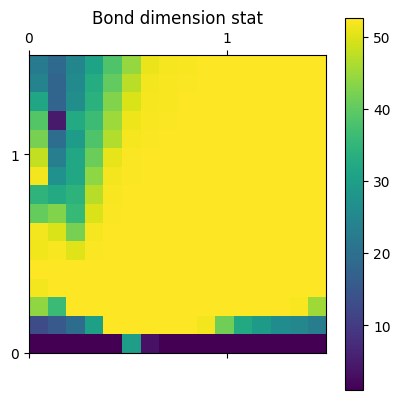

In [5]:
plt.matshow(bond_dim_map, origin='lower', extent=params_extent)
plt.title('Bond dimension stat')
plt.colorbar()

In [6]:
eps = params[1, 0] - params[0, 0]
eps

0.1

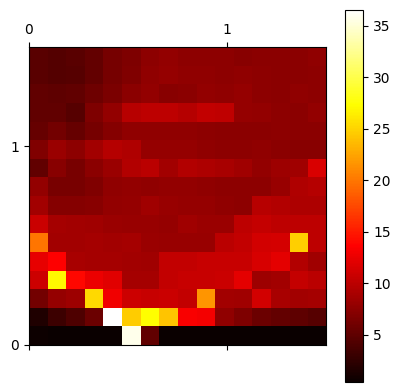

In [7]:
# Execution time per pixel.
plt.matshow(np.array(stats['times']).reshape((n, n)), cmap='hot', origin='lower', extent=params_extent)
plt.colorbar()

In [ ]:
# Old code for grad laplacian.

# g = fidelity_laplacian(rdms)
# grad_g = signal.convolve2d(g, SOBEL, boundary='symm', mode='same')
# g_grad_norm = g / np.abs(grad_g)
# params1, n1 = params, n

# plt.matshow(g_grad_norm[:32, :32], origin='lower', cmap='jet')
# plt.colorbar()

In [ ]:
# Export data for learning

# g_params = params.reshape((n, n, -1))[1:-1,1:-1]
# assert g_params.shape[:2] == g_grad_norm.shape[:2]

# filename = f'phaset-data-{str(uuid.uuid4())}.pkl' 
# with gzip.open(filename, 'wb') as f:
#     pickle.dump(dict(params=g_params, g_grad_norm=g_grad_norm, grad_g_norm=grad_g / np.abs(grad_g), g=g), f)

### Insert external rdms

In [4]:
def swap_rows(matrix, tensor: bool=True):
    n = len(matrix)
    for i in range(n // 2):
        row_to_swap = n - 1 - i
        if tensor:
            matrix[i, :, :], matrix[row_to_swap,: , :] = matrix[row_to_swap, :, :], matrix[i, :, :].copy()
        else:
            for row in matrix:
                row[i], row[row_to_swap] = row[row_to_swap], row[i]
    return matrix

In [5]:
L = 50
chi= 64
model = "ANNNI"
sites = 6
eps = 1e-5

hx_i = 0.01
hx_f = 1.5
hy_i = 0.01
hy_f = 1.5
delta = 64
grid_hx = np.linspace(hx_i, hx_f, delta)
# grid_h.reverse()
grid_hy = np.linspace(hy_i, hy_f, delta)

params = [[hx,hy] for hx in grid_hx for hy in grid_hy]
params_extent = np.concatenate([np.min(params, axis=0), np.max(params, axis=0)])
params_extent = tuple(params_extent[[0, 2, 1, 3]])

if model == "Ising":
    model_path = "0_ISING"
    param_labels = ["h","J"]

elif model == "Z2":
    model_path = "1_Z2"
    param_labels = ["g","J"]

elif model == "ANNNI":
    model_path = "2_ANNNI"
    param_labels = ["k","h"]

elif model == "Cluster":
    model_path = "3_CLUSTER"
    param_labels = ["h","J"]

elif model == "XXZ":
    model_path = "4_XXZ"
    param_labels = ["$\Delta$","h"]    
else:
    raise SyntaxError("Model not valid. Choose among 'Ising', 'Z2', 'ANNNI', 'Cluster', 'XXZ'")
path_rdms = f"/Users/fradm98/Google Drive/My Drive/projects/{model_path}"
path_rdms = f"/Users/fradm98/Desktop/fidelity-phase-tran"

# rdms = np.load(f"{path_rdms}/results/data/5_sites-rdms_dmrg_Cluster-XY_L_12_hx_-2.0-4.0_hy_-4.0-4.0_delta_10_degeneracy_method_0_eps_0.0_guess_path_chi_4.npy")
# rdms = np.load(f"{path_rdms}/results/rdms_data/{sites}_sites-rdms_{model}_L_{L}_h-j_{hx_i}-{hx_f}_delta_{delta}_degeneracy_method_1_guess_path.npy")
rdms = np.load(f"{path_rdms}/results/rdms_data/{sites}_sites-rdms_dmrg_{model}_L_{L}_hx_{hx_i}-{hx_f}_hy_{hy_i}-{hy_f}_delta_{delta}_degeneracy_method_1_eps_{eps}_guess_path_chi_{chi}.npy")
# rdms = rdms.reshape((delta,delta,2**sites,2**sites))
rdms = swap_rows(rdms)
# rdms = np.swapaxes(rdms, 0, 1)

In [6]:
# Grad laplacian filter with upsampling
kernel = bump_kernel(6, scale=2)
kernel = signal.convolve2d(kernel, SOBEL, boundary='symm', mode='same')

g = fidelity_laplacian(rdms)
# TODO Optional upsampling
g_up = upsampling_base(g)
# TODO Exclude boundaries, re-eval domain.
grad_g = signal.convolve2d(g_up, kernel, boundary='symm', mode='same')

# TODO Consider pixel centering.
n1 = len(grad_g)
n2 = len(grad_g)//2
params1 = params_2d_lattice(params_extent[:2], params_extent[2:], n=n1)

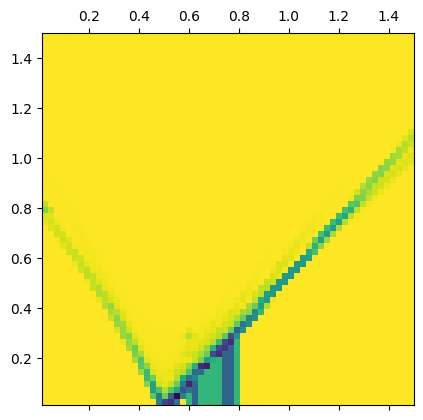

In [7]:
plt.matshow(g, origin='lower', extent=params_extent)

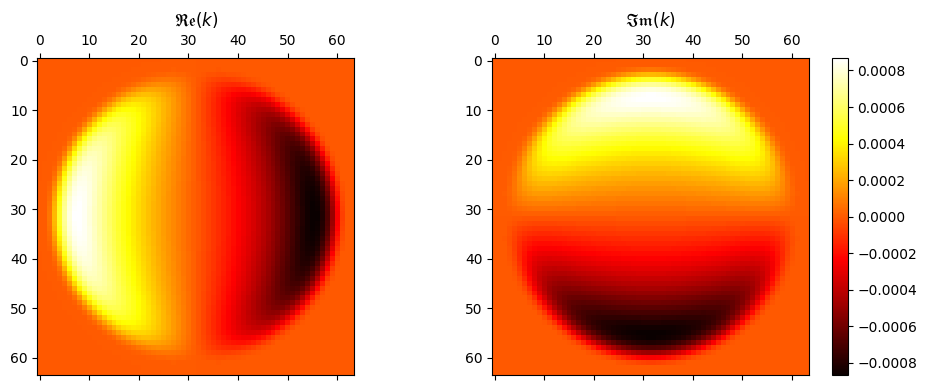

In [8]:
kernel = bump_kernel(64, scale=2)
kernel = signal.convolve2d(kernel, SOBEL, boundary='symm', mode='same')

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].set_title('$\\mathfrak{Re}(k)$')
axs[0].matshow(np.real(kernel), cmap='hot', aspect='equal')
axs[1].set_title('$\\mathfrak{Im}(k)$')
imgax = axs[1].matshow(np.imag(kernel), cmap='hot', aspect='equal')
plt.colorbar(imgax)
plt.tight_layout()

In [10]:
data = np.linspace(params_extent[2], params_extent[3], 50)
data_line, _ = BKT_tran(data)
print(data_line)

[0.11260587 0.17004635 0.2172333  0.25981478 0.2997599  0.33800466
 0.37506954 0.41127369 0.44682636 0.48187178 0.51651321 0.55082688
 0.58487047 0.61868858 0.65231627 0.68578155 0.7191071  0.75231149
 0.78541008 0.81841572 0.85133921 0.88418973 0.91697512 0.94970213
 0.98237659 1.01500357 1.04758752 1.08013233 1.11264142 1.14511786
 1.17756432 1.20998324 1.24237675]


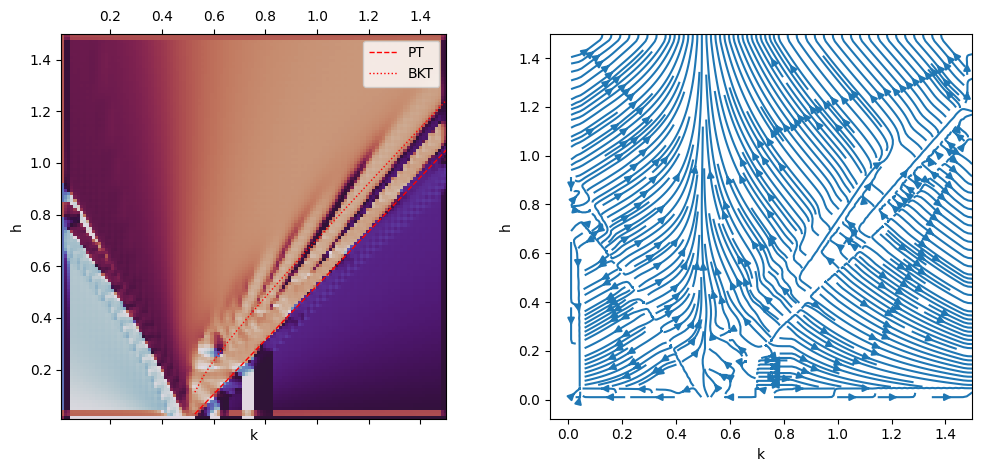

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].matshow(np.angle(grad_g), origin='lower', cmap='twilight', extent=params_extent, aspect='equal',
               vmin=-np.pi, vmax=np.pi)
# if markers is not None:
#     axs[0].scatter(markers[0], markers[1], marker='x', color='red')
th_lines(PT_tran, axs[0], params_extent, color='red', linestyle='--')
th_lines(BKT_tran, axs[0], params_extent, color='red', linestyle=':')
axs[0].set_xlabel(param_labels[0])
axs[0].set_ylabel(param_labels[1])
axs[0].legend()

X, Y = params1[:, 0].reshape((n1, n1)), params1[:, 1].reshape((n1, n1))
# if workflow_stable:
#    X, Y = X[1:-1, 1:-1], Y[1:-1, 1:-1]   # Used by stable algorithm.
#ngrad_g = np.abs(grad_g)[::2, ::2]
#axs[1].quiver(np.real(grad_g[::2, ::2])/ngrad_g, np.imag(grad_g[::2, ::2])/ngrad_g)
axs[1].streamplot(X, Y, np.real(grad_g), np.imag(grad_g), density=3)
axs[1].set_xlabel(param_labels[0])
axs[1].set_ylabel(param_labels[1]);

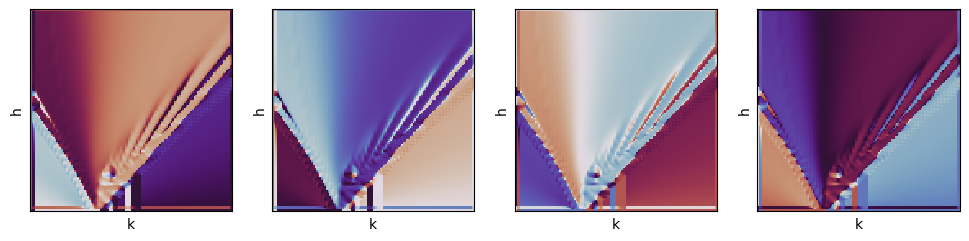

In [15]:
# Angle plots with different rotations of the colormap.
fig, axs = plt.subplots(1, 4, figsize=(12, 5))
for i, c in enumerate((1, -1, 1j, -1j)):
    axs[i].matshow(np.angle(grad_g * c), origin='lower', cmap='twilight', extent=params_extent, aspect='equal',
                   vmin=-np.pi, vmax=np.pi)
    axs[i].set_xlabel(param_labels[0])
    axs[i].set_ylabel(param_labels[1])
    axs[i].set_xticks([])
    axs[i].set_yticks([])

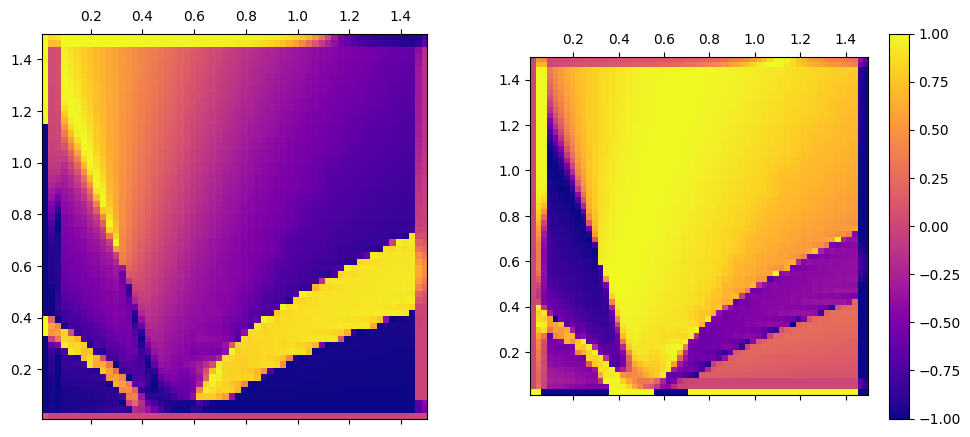

In [58]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
# Note we do not need cyclic colormaps for sin/cos of angle.
axs[0].matshow(np.cos(np.angle(grad_g)), origin='lower', cmap='plasma', extent=params_extent, aspect='equal', vmin=-1, vmax=1)
lastax = axs[1].matshow(np.sin(np.angle(grad_g)), origin='lower', cmap='plasma', extent=params_extent, aspect='equal', vmin=-1, vmax=1)
plt.colorbar(lastax)

In [ ]:
def avg_op(psi: MPS, op='Sigmaz', sites=None):
    v = psi.expectation_value(op, sites=sites)
    return v / len(v)

mags = np.array([avg_op(psi, op='Sz0', sites=[l // 2]) for psi in gstates])
mags = mags.reshape((n, n))

mag_dx = signal.convolve2d(mags, SOBEL_X, boundary='symm', mode='same')
mag_dy = signal.convolve2d(mags, SOBEL_X.T, boundary='symm', mode='same')
# grad_mag = signal.convolve2d(mag_dx - mag_dy, SOBEL, boundary='symm', mode='same')
grad_mag = signal.convolve2d(mag_dx, SOBEL, boundary='symm', mode='same')

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].set_title('Mag')
axs[0].matshow(mags, origin='lower', cmap='twilight')
axs[1].set_title('cos angle grad(mag_dx)')
axs[1].matshow(np.cos(np.angle(grad_mag)), origin='lower', cmap='twilight', vmin=-1, vmax=1)